<a href="https://colab.research.google.com/github/kukuhagushermawan/CVL_Assignment02/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CVL_Assignment02**
## **Object Detection Using Sliding Window with Manual Template Matching**

**Nama:** Kukuh Agus Hermawan  
**NIM:** 24/533395/PA/22573  
**Kelas:** KOM  

---

Pada notebook ini, saya mengimplementasikan metode sliding window untuk mendeteksi objek pada citra menggunakan template matching berbasis SSD.

Proses:
1. membaca input image dan template,
2. mengubah keduanya ke grayscale,
3. menggeser window seukuran template ke seluruh input image,
4. menghitung nilai SSD pada setiap window,
5. memilih window dengan SSD minimum sebagai hasil deteksi,
6. menghitung IoU dan accuracy.

## **1. Metode**

Sliding window bekerja dengan cara menggeser sebuah window ke seluruh area gambar untuk mencari objek.

Pada implementasi ini:
- representasi objek menggunakan pixel intensity grayscale.
- scoring kandidat menggunakan SSD (Sum of Squared Differences).

Rumus SSD:

$$
\mathrm{SSD} = \sum (W - T)^2
$$

dengan:
- \(W\) = window pada gambar
- \(T\) = template

Semakin kecil nilai SSD, semakin mirip window tersebut dengan template.

In [1]:
import os # For File Handling
import numpy as np # For Numeric Computation
import matplotlib.pyplot as plt # For Image Display
from PIL import Image # For Reading Image
from urllib.request import urlopen # For Loading Image from URL
from io import BytesIO # For Reading Image Bytes

## **2. Menentukan File Input**

Gunakan dua file gambar yang disimpan pada repository GitHub:
- `input.png`
- `template.png`

Catatan:
- `input.png` = gambar input yang akan dideteksi
- `template.png` = template wajah karakter yang ingin dicari (Gojo)

In [2]:
input_path = "https://raw.githubusercontent.com/kukuhagushermawan/CVL_Assignment02/main/images/input.png"
template_path = "https://raw.githubusercontent.com/kukuhagushermawan/CVL_Assignment02/main/images/template.png"

stride = 1   # jarak geser window

## **3. Persiapan Citra**

Bagian ini berisi fungsi untuk:
- membaca gambar,
- mengubah RGB ke grayscale,
- menampilkan gambar,
- menggambar bounding box.

In [3]:
def load_image_rgb(path):
    if path.startswith("http://") or path.startswith("https://"):
        response = urlopen(path)
        image = Image.open(BytesIO(response.read())).convert("RGB")
    else:
        image = Image.open(path).convert("RGB")
    return np.array(image, dtype=np.uint8)

def rgb_to_gray(image_rgb):
    r = image_rgb[:, :, 0].astype(np.float64)
    g = image_rgb[:, :, 1].astype(np.float64)
    b = image_rgb[:, :, 2].astype(np.float64)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.uint8)

def show_two_images(img1, title1, img2, title2, cmap1=None, cmap2=None, figsize=(12, 5)):
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    if img1.ndim == 2:
        plt.imshow(img1, cmap="gray" if cmap1 is None else cmap1)
    else:
        plt.imshow(img1)
    plt.title(title1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    if img2.ndim == 2:
        plt.imshow(img2, cmap="gray" if cmap2 is None else cmap2)
    else:
        plt.imshow(img2)
    plt.title(title2)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def draw_box(image_rgb, box, color=(0, 255, 0), thickness=3):
    out = image_rgb.copy()
    x, y, w, h = box

    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(out.shape[1] - 1, x + w - 1)
    y2 = min(out.shape[0] - 1, y + h - 1)

    for t in range(thickness):
        if y1 + t <= y2:
            out[y1 + t, x1:x2 + 1] = color
        if y2 - t >= y1:
            out[y2 - t, x1:x2 + 1] = color
        if x1 + t <= x2:
            out[y1:y2 + 1, x1 + t] = color
        if x2 - t >= x1:
            out[y1:y2 + 1, x2 - t] = color

    return out

## **4. Membaca Input dan Template**

Input image dan template dibaca lalu diubah ke grayscale.

In [4]:
input_rgb = load_image_rgb(input_path)
template_rgb = load_image_rgb(template_path)

input_gray = rgb_to_gray(input_rgb)
template_gray = rgb_to_gray(template_rgb)

input_h, input_w = input_gray.shape
template_h, template_w = template_gray.shape

print("Ukuran input    :", input_rgb.shape)
print("Ukuran template :", template_rgb.shape)
print("Template width  :", template_w)
print("Template height :", template_h)

Ukuran input    : (600, 1066, 3)
Ukuran template : (114, 114, 3)
Template width  : 114
Template height : 114


## **5. Menampilkan Input dan Template**

Bagian ini digunakan untuk memastikan gambar yang dipakai sudah benar.

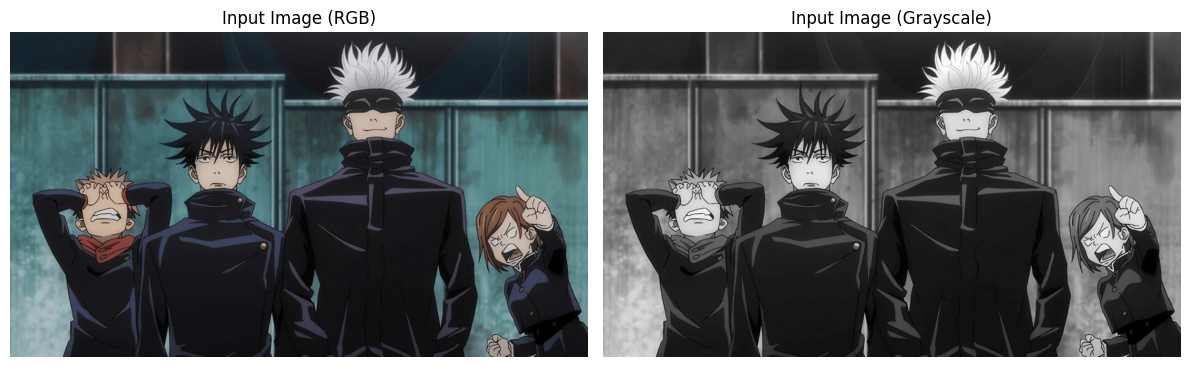

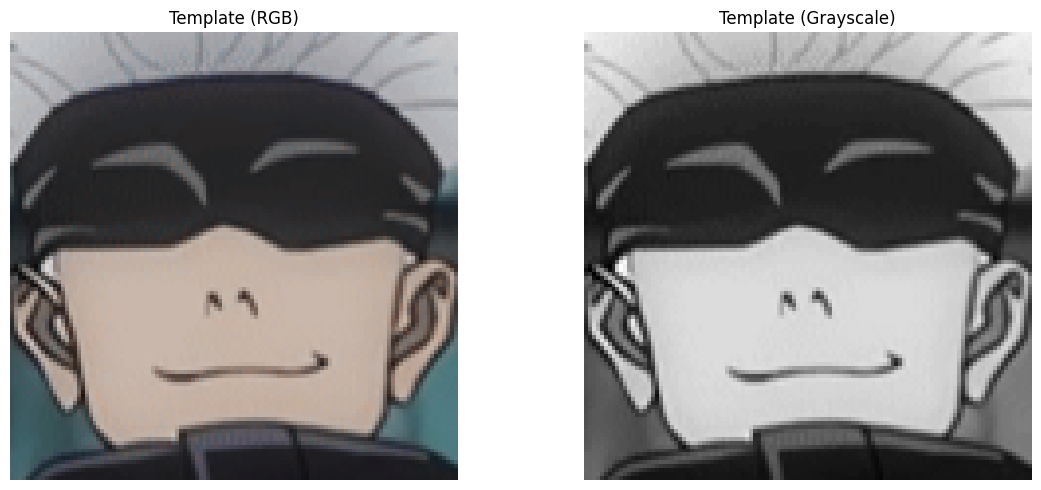

In [5]:
show_two_images(
    input_rgb, "Input Image (RGB)",
    input_gray, "Input Image (Grayscale)",
    cmap1=None, cmap2="gray"
)

show_two_images(
    template_rgb, "Template (RGB)",
    template_gray, "Template (Grayscale)",
    cmap1=None, cmap2="gray"
)

## **6. Menampilkan Koordinat Input**

Bagian ini digunakan untuk memperkirakan posisi objek target pada input image.

Setelah melihat koordinatnya, isi ground truth pada cell berikutnya.

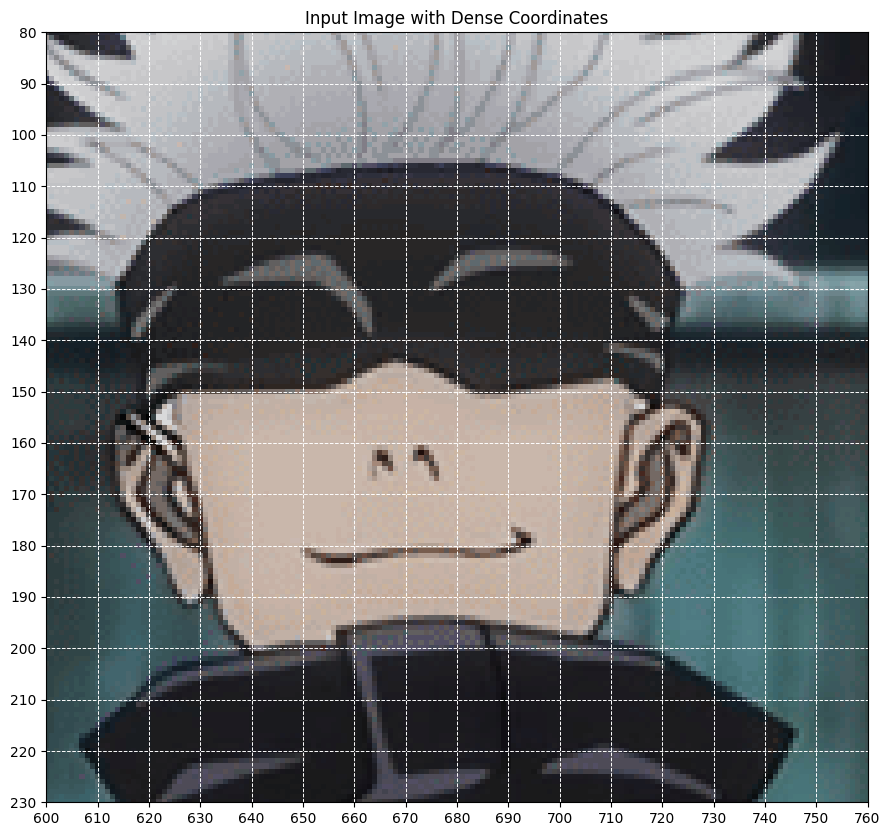

In [6]:
plt.figure(figsize=(14, 10))
plt.imshow(input_rgb)
plt.title("Input Image with Dense Coordinates")

# zoom ke area target (wajah Gojo)
plt.xlim(600, 760)
plt.ylim(230, 80)

plt.xticks(np.arange(600, 761, 10))
plt.yticks(np.arange(80, 231, 10))
plt.grid(color='white', linestyle='--', linewidth=0.7)

plt.show()

## **7. Mengisi Ground Truth**

Isi koordinat kiri-atas objek yang benar pada input image.

Format:
- `gt_x` = posisi x kiri-atas
- `gt_y` = posisi y kiri-atas

Ukuran ground truth otomatis sama dengan ukuran template.

In [7]:
# saya isi secara manual sesuai pengamatan koordinat di atas
gt_x = 615
gt_y = 91

gt_box = (gt_x, gt_y, template_w, template_h)

print("Ground Truth Box:", gt_box)

Ground Truth Box: (615, 91, 114, 114)


## **8. Sliding Window dan SSD**

Template digeser ke seluruh input image. Setiap window dibandingkan dengan template menggunakan SSD.

Pada implementasi ini, ukuran window tetap dan selalu sama dengan ukuran template. Jadi metode yang digunakan merupakan sliding window single scale, bukan multiscale. Window hanya berpindah posisi pada input image, tanpa mengubah ukuran template maupun ukuran window.

Ukuran result map:
- tinggi = H - h + 1
- lebar = W - w + 1

In [8]:
def sliding_window_ssd(image_gray, template_gray, stride=1):
    H, W = image_gray.shape
    h, w = template_gray.shape

    ys = list(range(0, H - h + 1, stride))
    xs = list(range(0, W - w + 1, stride))

    ssd_map = np.zeros((len(ys), len(xs)), dtype=np.float64)
    template_f = template_gray.astype(np.float64)

    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            window = image_gray[y:y+h, x:x+w].astype(np.float64)
            diff = window - template_f
            ssd = np.sum(diff * diff)
            ssd_map[i, j] = ssd

    return ssd_map, ys, xs

def find_best_match(ssd_map, ys, xs):
    idx = np.argmin(ssd_map)
    i, j = np.unravel_index(idx, ssd_map.shape)

    best_y = ys[i]
    best_x = xs[j]
    best_score = ssd_map[i, j]

    return best_x, best_y, best_score

## **9. Running Deteksi**

Seluruh window berukuran sama dengan template diperiksa pada input image.
Window dengan nilai SSD minimum dipilih sebagai hasil deteksi.

In [9]:
ssd_map, ys, xs = sliding_window_ssd(input_gray, template_gray, stride=stride)
best_x, best_y, best_score = find_best_match(ssd_map, ys, xs)

pred_box = (best_x, best_y, template_w, template_h)

print("Predicted Box :", pred_box)
print("Best SSD      :", best_score)
print("SSD Map Shape :", ssd_map.shape)

Predicted Box : (614, 95, 114, 114)
Best SSD      : 1533995.0
SSD Map Shape : (487, 953)


## **10. Menampilkan Matching Result**

Bagian ini menampilkan:
- SSD map
- lokasi deteksi pada input image

Karena menggunakan squared difference, lokasi terbaik adalah nilai minimum.

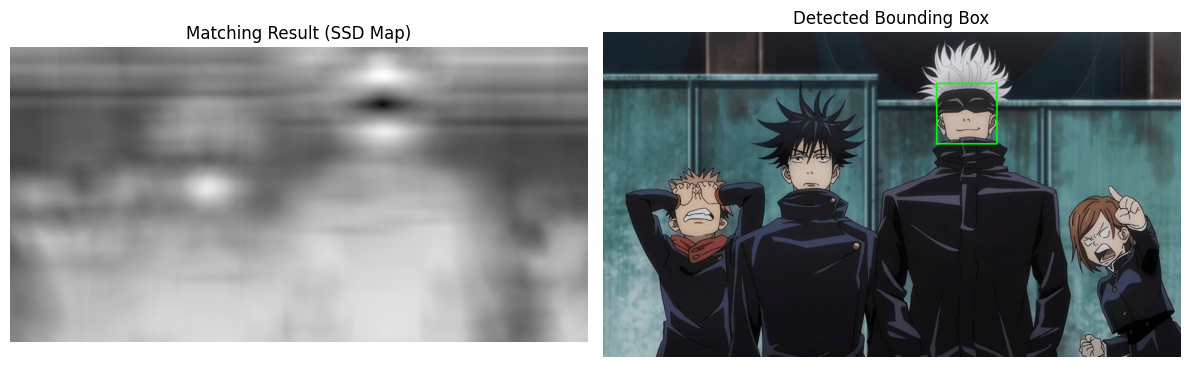

In [10]:
ssd_vis = (ssd_map - ssd_map.min()) / (ssd_map.max() - ssd_map.min() + 1e-8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ssd_vis, cmap="gray")
plt.title("Matching Result (SSD Map)")
plt.axis("off")

det_vis = draw_box(input_rgb, pred_box, color=(0, 255, 0), thickness=3)
plt.subplot(1, 2, 2)
plt.imshow(det_vis)
plt.title("Detected Bounding Box")
plt.axis("off")

plt.tight_layout()
plt.show()

## **11. Menampilkan Prediksi dan Ground Truth**

- Hijau = prediksi
- Merah = ground truth

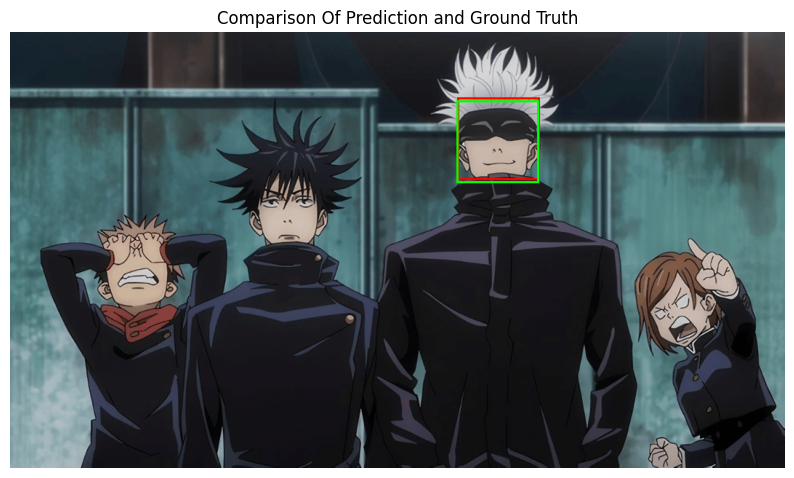

In [11]:
compare_vis = draw_box(input_rgb, gt_box, color=(255, 0, 0), thickness=3)
compare_vis = draw_box(compare_vis, pred_box, color=(0, 255, 0), thickness=3)

plt.figure(figsize=(10, 6))
plt.imshow(compare_vis)
plt.title("Comparison Of Prediction and Ground Truth")
plt.axis("off")
plt.show()

## **12. Menghitung IoU dan Accuracy**

Evaluasi dilakukan dengan:
- IoU = overlap antara prediksi dan ground truth
- Accuracy = 1 jika IoU >= 0.5, dan 0 jika tidak

In [12]:
def calculate_iou(box_pred, box_gt):
    x1_p, y1_p, w_p, h_p = box_pred
    x1_g, y1_g, w_g, h_g = box_gt

    x2_p = x1_p + w_p
    y2_p = y1_p + h_p
    x2_g = x1_g + w_g
    y2_g = y1_g + h_g

    inter_x1 = max(x1_p, x1_g)
    inter_y1 = max(y1_p, y1_g)
    inter_x2 = min(x2_p, x2_g)
    inter_y2 = min(y2_p, y2_g)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    area_pred = w_p * h_p
    area_gt = w_g * h_g
    union = area_pred + area_gt - intersection

    if union == 0:
        return 0.0

    return intersection / union

def calculate_accuracy(iou, threshold=0.5):
    return 1 if iou >= threshold else 0

iou = calculate_iou(pred_box, gt_box)
accuracy = calculate_accuracy(iou, threshold=0.5)

print(f"Predicted: ({best_x}, {best_y})")
print(f"Ground Truth: ({gt_x}, {gt_y})")
print(f"IoU: {iou:.4f}")
print(f"Accuracy (IoU >= 0.5): {accuracy}")

Predicted: (614, 95)
Ground Truth: (615, 91)
IoU: 0.9165
Accuracy (IoU >= 0.5): 1


## **13. Analisis Hasil**

Pada percobaan ini, metode sliding window dengan template matching berbasis SSD (Sum of Squared Differences) digunakan untuk mendeteksi objek pada input image berukuran 600 × 1066 × 3 dengan template berukuran 114 × 114 × 3. Proses deteksi dilakukan dengan membandingkan template terhadap seluruh window pada input image, kemudian memilih window dengan nilai SSD minimum sebagai hasil prediksi.

Berdasarkan hasil yang diperoleh, ground truth box berada pada koordinat (615, 91, 114, 114), sedangkan predicted box berada pada koordinat (614, 95, 114, 114). Selisih posisi prediksi terhadap ground truth hanya 1 piksel pada sumbu x dan 4 piksel pada sumbu y, sehingga dapat dikatakan bahwa lokasi objek berhasil ditemukan dengan sangat dekat. Nilai Best SSD yang diperoleh adalah 1533995.0, dengan ukuran SSD map = (487, 953).

Hasil evaluasi menunjukkan nilai IoU sebesar 0.9165 dan accuracy sebesar 1 dengan threshold IoU ≥ 0.5. Nilai IoU yang tinggi menunjukkan bahwa area bounding box prediksi memiliki tumpang tindih yang sangat besar dengan ground truth. Dengan demikian, pada citra uji ini metode berhasil mendeteksi objek target (wajah Gojo) dengan baik.

Keberhasilan tersebut dipengaruhi oleh tingginya kemiripan visual antara template dan objek target pada input image. Karena ukuran, bentuk, dan tampilan objek target relatif sesuai dengan template, maka window yang memiliki SSD minimum dapat merepresentasikan lokasi objek secara tepat. Namun, hasil ini perlu dipahami sebagai keberhasilan pada satu sampel uji, sehingga belum cukup untuk menyimpulkan bahwa metode akan selalu memberikan performa yang sama pada berbagai variasi citra.

### **Kelebihan**
- hasil deteksi pada citra uji ini sangat baik, terlihat dari nilai IoU 0.9165 yang menunjukkan prediksi sangat dekat dengan ground truth
- bounding box prediksi hampir sama dengan ground truth, sehingga lokasi objek dapat ditemukan dengan jelas
- metode mampu mendeteksi objek target utama secara tepat ketika tampilan objek pada gambar mirip dengan template
- visualisasi hasil deteksi mudah dipahami karena lokasi prediksi dapat langsung dibandingkan dengan ground truth

### **Keterbatasan**
- hasil yang baik pada percobaan ini belum tentu langsung mewakili performa metode secara umum karena pengujian masih dilakukan pada satu input image
- performa dapat menurun jika ukuran objek pada input image berbeda jauh dari ukuran template
- hasil deteksi dapat menjadi kurang stabil jika objek mengalami rotasi, perubahan sudut, atau perubahan pencahayaan
- metode kurang efektif jika terdapat banyak area pada gambar yang memiliki tampilan mirip dengan template
- proses sliding window membutuhkan komputasi yang cukup besar karena seluruh area gambar diperiksa, terutama jika ukuran gambar besar dan stride kecil
- ground truth masih ditentukan secara manual berdasarkan pengamatan koordinat grid, sehingga evaluasi masih memiliki kemungkinan subjektivitas

### **Kesimpulan**
Berdasarkan hasil percobaan ini, metode sliding window dengan SSD berhasil mendeteksi objek target dengan baik pada citra yang digunakan. Hal ini ditunjukkan oleh nilai IoU sebesar 0.9165 dan Accuracy sebesar 1, yang menandakan bahwa bounding box prediksi sangat mendekati ground truth. Namun, hasil pada percobaan ini diperoleh pada citra dengan objek yang sangat mirip dengan template. Oleh karena itu, pengujian pada data yang lebih beragam masih diperlukan agar performa metode dapat dinilai secara lebih menyeluruh.